In [ ]:
import torch
import torchvision
from torchvision.transforms import ToTensor, Normalize, Compose
from torchvision.datasets import FashionMNIST

# Load Fashion MNIST dataset
fashion_mnist = FashionMNIST(root='data',
                             train=True,
                             download=True,
                             transform=Compose([ToTensor(), Normalize(mean=(0.5,), std=(0.5,))]))

100%|██████████| 26421880/26421880 [01:45<00:00, 249921.41it/s] 


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 198621.92it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:11<00:00, 395602.20it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 11909694.98it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [ ]:
# Retrieve the first image and label from the dataset
img, label = fashion_mnist[0]

# Display the label and a slice of the image tensor
print('Label: ', label)
print(img[:,10:15,10:15])

# Check min and max pixel values
torch.min(img), torch.max(img)

Label:  9
tensor([[[-1.0000, -1.0000, -1.0000,  0.5137,  0.7882],
         [-0.9765, -1.0000, -0.9059,  0.7176,  0.7255],
         [-0.9529, -1.0000, -0.2235,  0.9137,  0.7412],
         [-1.0000, -1.0000, -0.5686,  0.8510,  0.7882],
         [-1.0000, -1.0000,  0.8588,  0.7725,  0.7020]]])


(tensor(-1.), tensor(1.))

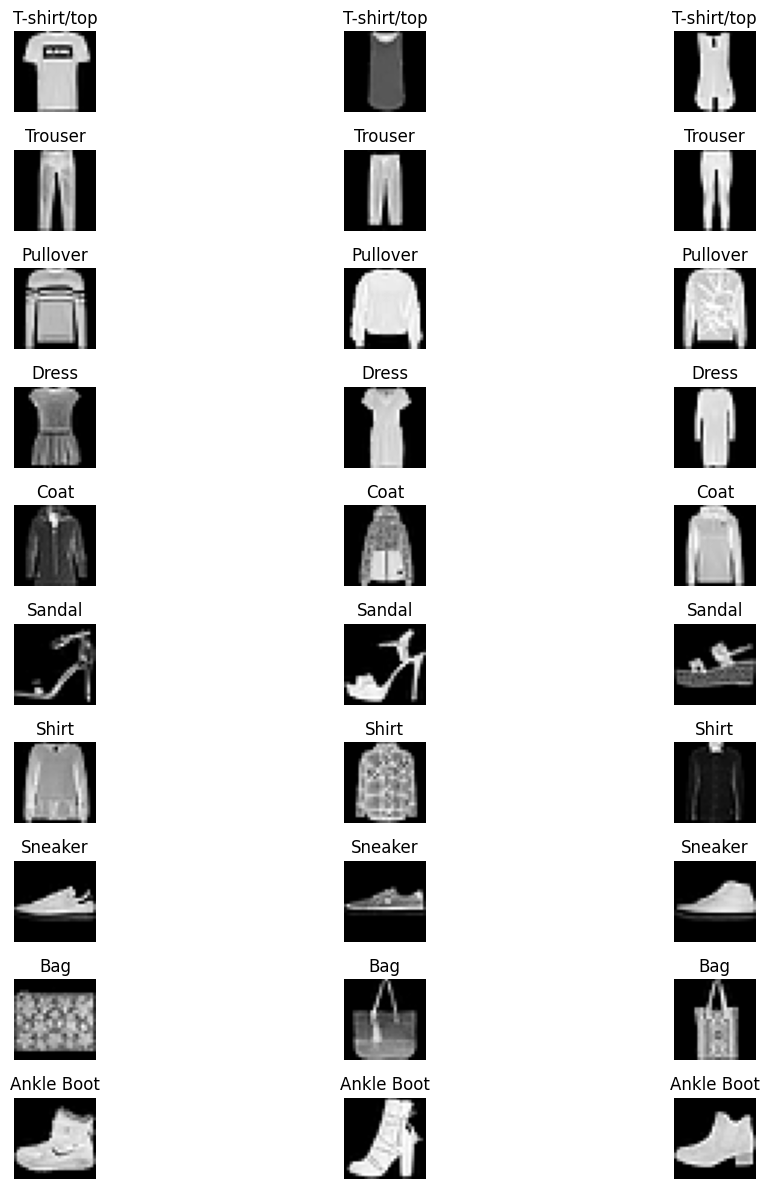

In [ ]:
import torch
import torchvision
from torchvision.transforms import ToTensor, Normalize, Compose
from torchvision.datasets import FashionMNIST
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset
fashion_mnist = FashionMNIST(root='data',
                             train=True,
                             download=True,
                             transform=Compose([ToTensor(), Normalize(mean=(0.5,), std=(0.5,))]))

# Dictionary to keep track of the number of images per label
label_count = {i: 0 for i in range(10)}
max_images_per_label = 3

# Create a mapping of label indices to label names for Fashion MNIST
label_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

# Plotting 3 images for each label
plt.figure(figsize=(12, 12))

for img, label in fashion_mnist:
    if label_count[label] < max_images_per_label:
        label_count[label] += 1
        plt.subplot(10, 3, label * 3 + label_count[label])
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(label_names[label])
        plt.axis('off')

    # Stop once we've collected 3 images for each label
    if all(count == max_images_per_label for count in label_count.values()):
        break
plt.tight_layout()
plt.show()

In [ ]:
def denorm(x):
    out = (x + 1) / 2
    return out.clamp(0, 1)

Label: 9


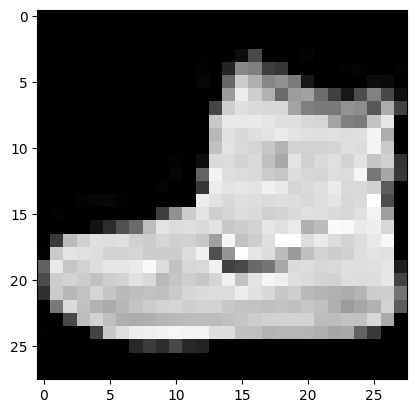

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

img_norm = denorm(img)
plt.imshow(img_norm[0], cmap='gray')
print('Label:', label)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 100
data_loader = DataLoader(fashion_mnist, batch_size, shuffle=True)

first batch
torch.Size([100, 1, 28, 28])
tensor([6, 4, 0, 3, 8, 4, 8, 5, 5, 0, 7, 4, 3, 8, 5, 5, 7, 7, 4, 8, 1, 7, 0, 9,
        7, 3, 0, 6, 0, 4, 8, 1, 7, 0, 2, 5, 4, 5, 8, 3, 5, 7, 0, 7, 8, 5, 8, 7,
        5, 2, 4, 8, 3, 0, 7, 2, 7, 6, 1, 5, 8, 9, 6, 8, 6, 6, 6, 1, 3, 0, 7, 9,
        9, 8, 4, 2, 5, 4, 4, 6, 6, 5, 6, 8, 2, 6, 1, 0, 9, 0, 3, 8, 6, 1, 6, 2,
        2, 2, 0, 8])


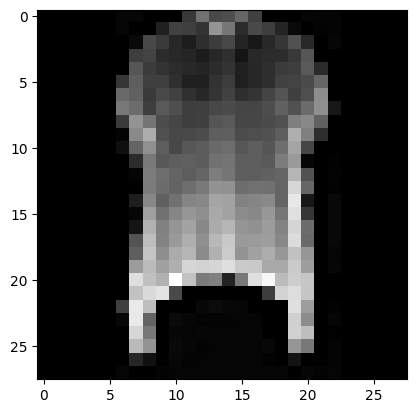

In [ ]:
for img_batch, label_batch in data_loader:
    print('first batch')
    print(img_batch.shape)
    plt.imshow(img_batch[0][0], cmap='gray')
    print(label_batch)
    break

In [ ]:


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
device

device(type='cuda')

Network

In [ ]:
image_size = 784
hidden_size = 256

In [ ]:
import torch.nn as nn

D = nn.Sequential(
    nn.Linear(image_size, hidden_size),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, hidden_size),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, 1),
    nn.Sigmoid())

In [ ]:
D.to(device);

Generaror Network

In [ ]:
latent_size = 64

In [ ]:
G = nn.Sequential(
    nn.Linear(latent_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, image_size),
    nn.Tanh())

In [ ]:
y = G(torch.randn(2, latent_size))
gen_imgs = denorm(y.reshape((-1, 28,28)).detach())

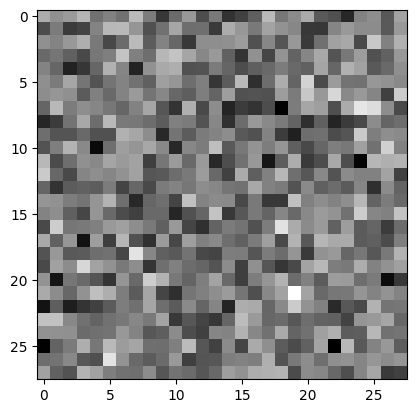

In [ ]:
plt.imshow(gen_imgs[0], cmap='gray');

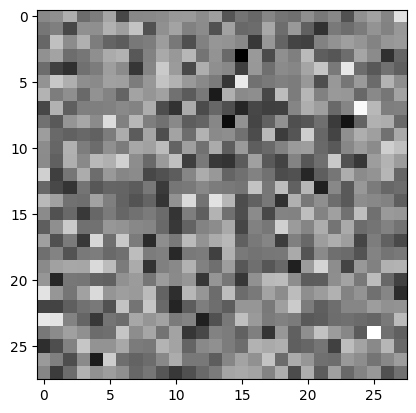

In [ ]:
plt.imshow(gen_imgs[1], cmap='gray');

In [ ]:
G.to(device);

Discriminator Training

In [ ]:
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002)

In [ ]:
def reset_grad():
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

def train_discriminator(images):
    # Create the labels which are later used as input for the BCE loss
    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Loss for real images
    outputs = D(images)
    d_loss_real = criterion(outputs, real_labels)
    real_score = outputs

    # Loss for fake images
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    outputs = D(fake_images)
    d_loss_fake = criterion(outputs, fake_labels)
    fake_score = outputs

    # Combine losses
    d_loss = d_loss_real + d_loss_fake
    # Reset gradients
    reset_grad()
    # Compute gradients
    d_loss.backward()
    # Adjust the parameters using backprop
    d_optimizer.step()

    return d_loss, real_score, fake_score

Generator Training

In [ ]:
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)

In [ ]:
def train_generator():
    # Generate fake images and calculate loss
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    labels = torch.ones(batch_size, 1).to(device)
    g_loss = criterion(D(fake_images), labels)

    # Backprop and optimize
    reset_grad()
    g_loss.backward()
    g_optimizer.step()
    return g_loss, fake_images

Training the model

In [ ]:
import os

sample_dir = 'samples'
if not os.path.exists(sample_dir):
    os.makedirs(sample_dir)

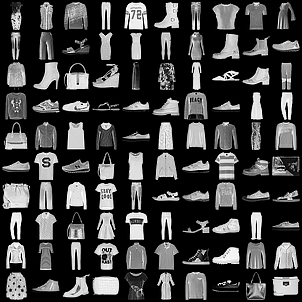

In [ ]:
#saving a batch of real images
from IPython.display import Image
from torchvision.utils import save_image

# Save some real images
for images, _ in data_loader:
    images = images.reshape(images.size(0), 1, 28, 28)
    save_image(denorm(images), os.path.join(sample_dir, 'real_images.png'), nrow=10)
    break

Image(os.path.join(sample_dir, 'real_images.png'))

Saving fake_images-0000.png


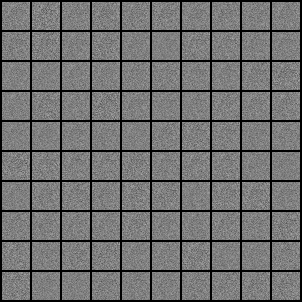

In [ ]:
sample_vectors = torch.randn(batch_size, latent_size).to(device)

def save_fake_images(index):
    fake_images = G(sample_vectors)
    fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
    fake_fname = 'fake_images-{0:0=4d}.png'.format(index)
    print('Saving', fake_fname)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=10)

# Before training
save_fake_images(0)
Image(os.path.join(sample_dir, 'fake_images-0000.png'))

In [ ]:
%%time

num_epochs = 200
total_step = len(data_loader)
d_losses, g_losses, real_scores, fake_scores = [], [], [], []

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        # Load a batch & transform to vectors
        images = images.reshape(batch_size, -1).to(device)

        # Train the discriminator and generator
        d_loss, real_score, fake_score = train_discriminator(images)
        g_loss, fake_images = train_generator()

        # Inspect the losses
        if (i+1) % 200 == 0:
            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())
            real_scores.append(real_score.mean().item())
            fake_scores.append(fake_score.mean().item())
            print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}'
                  .format(epoch, num_epochs, i+1, total_step, d_loss.item(), g_loss.item(),
                          real_score.mean().item(), fake_score.mean().item()))

    # Sample and save images
    save_fake_images(epoch+1)

Epoch [0/200], Step [200/600], d_loss: 0.0787, g_loss: 4.1001, D(x): 0.97, D(G(z)): 0.05
Epoch [0/200], Step [400/600], d_loss: 0.2153, g_loss: 5.2503, D(x): 0.95, D(G(z)): 0.11
Epoch [0/200], Step [600/600], d_loss: 0.0284, g_loss: 4.8633, D(x): 0.99, D(G(z)): 0.02
Saving fake_images-0001.png
Epoch [1/200], Step [200/600], d_loss: 0.0415, g_loss: 4.6875, D(x): 0.99, D(G(z)): 0.02
Epoch [1/200], Step [400/600], d_loss: 0.0510, g_loss: 4.9929, D(x): 0.98, D(G(z)): 0.03
Epoch [1/200], Step [600/600], d_loss: 0.0266, g_loss: 5.9098, D(x): 0.99, D(G(z)): 0.01
Saving fake_images-0002.png
Epoch [2/200], Step [200/600], d_loss: 0.0410, g_loss: 6.0431, D(x): 0.99, D(G(z)): 0.01
Epoch [2/200], Step [400/600], d_loss: 0.1813, g_loss: 6.6186, D(x): 1.00, D(G(z)): 0.14
Epoch [2/200], Step [600/600], d_loss: 0.0260, g_loss: 8.6083, D(x): 0.99, D(G(z)): 0.00
Saving fake_images-0003.png
Epoch [3/200], Step [200/600], d_loss: 0.1425, g_loss: 4.8374, D(x): 0.99, D(G(z)): 0.11
Epoch [3/200], Step [400/6

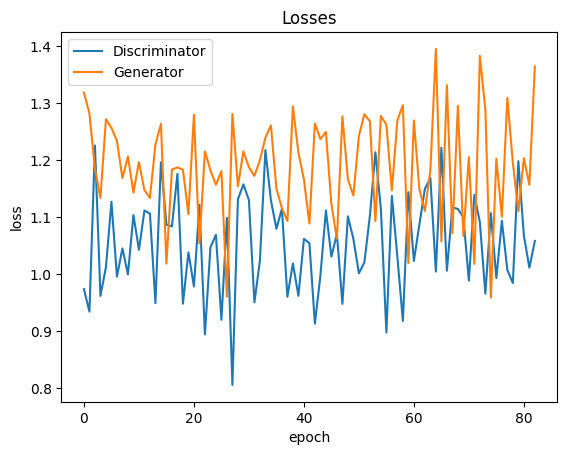

In [ ]:
plt.plot(d_losses, '-')
plt.plot(g_losses, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

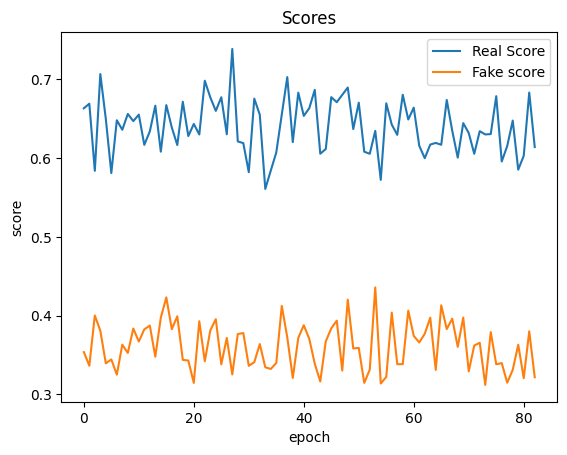

In [ ]:
plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real Score', 'Fake score'])
plt.title('Scores');

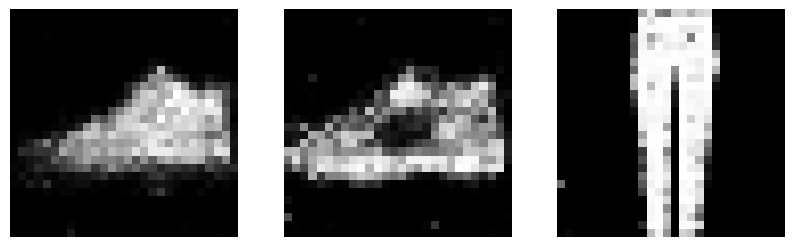

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to save and display 3 samples from your GAN model
def save_and_display_samples(num_samples=3):
    # Generate fake images
    fake_images = G(sample_vectors)
    fake_images = fake_images.reshape(fake_images.size(0), 28, 28).cpu().data.numpy()

    # Normalize the images back to [0,1] range
    fake_images = (fake_images + 1) / 2.0

    # Save and display the first 3 images
    fig, axes = plt.subplots(1, num_samples, figsize=(10, 5))

    for i in range(num_samples):
        axes[i].imshow(fake_images[i], cmap='gray')
        axes[i].axis('off')
        plt.savefig(f'sample_{i+1}.png')  # Save each sample as an image file
    plt.show()

# Call the function to save and display 3 samples
save_and_display_samples()


Challenges You Might Face
A common issue with GANs where the generator produces very similar images, resulting in a lack of diversity. we might observe that the 3 samples we save look almost identical.

Training Instability: If we notice noisy or unrealistic images, it could be due to instability during training. GANs are notoriously difficult to train because the generator and discriminator are constantly competing.

Visualization Issues: Saving images from tensors that are normalized can sometimes lead to visual issues like dark images or images with low contrast. In the code above, I included the step to denormalize the images, which should help with visualization.

In [ ]:
# Save the model checkpoints
torch.save(G.state_dict(), 'G.ckpt')
torch.save(D.state_dict(), 'D.ckpt')

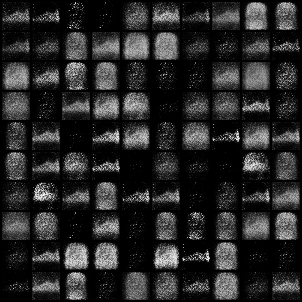

In [ ]:
Image('./samples/fake_images-0010.png')

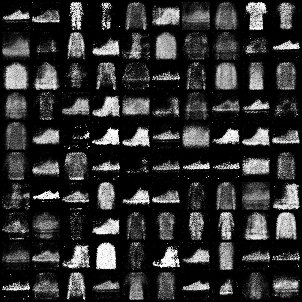

In [ ]:
Image('./samples/fake_images-0050.png')

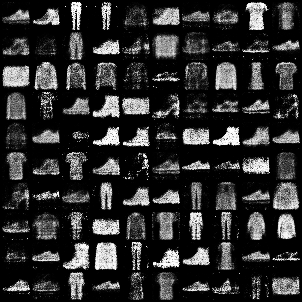

In [ ]:
Image('./samples/fake_images-0100.png')

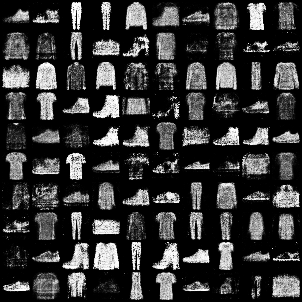

In [ ]:
Image('./samples/fake_images-0200.png')

Saving the model weights

In [ ]:
import os

# Define the directory to save the model weights
model_dir = 'model_weights'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the weights for the generator and discriminator models
torch.save(G.state_dict(), os.path.join(model_dir, 'generator.pth'))
torch.save(D.state_dict(), os.path.join(model_dir, 'discriminator.pth'))

print("successfully saved model weights")

successfully saved model weights


loading model weights

In [ ]:
# Load the saved generator and discriminator weights
G.load_state_dict(torch.load(os.path.join(model_dir, 'generator.pth')))
D.load_state_dict(torch.load(os.path.join(model_dir, 'discriminator.pth')))

print("successfully loaded model weights")

successfully loaded model weights


Retraining the GAN model to see improvement

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define loss function (Binary Cross-Entropy Loss)
criterion = nn.BCELoss()

# Define optimizers with potentially adjusted learning rates
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0001)  # Slightly reduce learning rate for improvement
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0001)

# Training function remains similar
def reset_grad():
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

In [ ]:
def train_discriminator(images):
    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Train with real images
    outputs = D(images)
    d_loss_real = criterion(outputs, real_labels)
    real_score = outputs

    # Train with fake images
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    outputs = D(fake_images)
    d_loss_fake = criterion(outputs, fake_labels)
    fake_score = outputs

    # Combine the losses
    d_loss = d_loss_real + d_loss_fake

    # Backprop and update
    reset_grad()
    d_loss.backward()
    d_optimizer.step()

    return d_loss, real_score, fake_score

def train_generator():
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    labels = torch.ones(batch_size, 1).to(device)  # Real labels for the fake images
    g_loss = criterion(D(fake_images), labels)

    # Backprop and optimize
    reset_grad()
    g_loss.backward()
    g_optimizer.step()

    return g_loss, fake_images

In [ ]:
# Re-training process
num_epochs = 400  # You can continue training for additional epochs
total_step = len(data_loader)
d_losses, g_losses, real_scores, fake_scores = [], [], [], []

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        # Prepare real images
        images = images.reshape(batch_size, -1).to(device)

        # Train the discriminator and generator
        d_loss, real_score, fake_score = train_discriminator(images)
        g_loss, fake_images = train_generator()

        # Inspect the losses
        if (i+1) % 200 == 0:
            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())
            real_scores.append(real_score.mean().item())
            fake_scores.append(fake_score.mean().item())
            print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}'
                  .format(epoch, num_epochs, i+1, total_step, d_loss.item(), g_loss.item(),
                          real_score.mean().item(), fake_score.mean().item()))

    # Save generated samples periodically
    save_fake_images(epoch+1)

Epoch [0/400], Step [200/600], d_loss: 1.1251, g_loss: 1.0704, D(x): 0.65, D(G(z)): 0.41
Epoch [0/400], Step [400/600], d_loss: 1.2027, g_loss: 1.1608, D(x): 0.58, D(G(z)): 0.38
Epoch [0/400], Step [600/600], d_loss: 1.1619, g_loss: 1.0303, D(x): 0.65, D(G(z)): 0.42
Saving fake_images-0001.png
Epoch [1/400], Step [200/600], d_loss: 0.8974, g_loss: 1.1650, D(x): 0.68, D(G(z)): 0.32
Epoch [1/400], Step [400/600], d_loss: 1.1277, g_loss: 1.1814, D(x): 0.61, D(G(z)): 0.38
Epoch [1/400], Step [600/600], d_loss: 1.0452, g_loss: 1.1431, D(x): 0.63, D(G(z)): 0.35
Saving fake_images-0002.png
Epoch [2/400], Step [200/600], d_loss: 0.8455, g_loss: 1.2919, D(x): 0.70, D(G(z)): 0.33
Epoch [2/400], Step [400/600], d_loss: 1.0182, g_loss: 1.2828, D(x): 0.64, D(G(z)): 0.33
Epoch [2/400], Step [600/600], d_loss: 1.0566, g_loss: 1.1210, D(x): 0.68, D(G(z)): 0.40
Saving fake_images-0003.png
Epoch [3/400], Step [200/600], d_loss: 0.9322, g_loss: 1.1534, D(x): 0.70, D(G(z)): 0.37
Epoch [3/400], Step [400/6

Saving the re-trained model

In [ ]:
import os

# Define a directory to save the model weights
model_dir = 'model_weights'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the weights of the Generator and Discriminator
torch.save(G.state_dict(), os.path.join(model_dir, 'generator_weights.pth'))
torch.save(D.state_dict(), os.path.join(model_dir, 'discriminator_weights.pth'))

print("Successfully saved model weights without using checkpoints.")

Successfully saved model weights without using checkpoints.


Loading the re-trained model

In [ ]:
# Load the saved model weights for both Generator and Discriminator
G.load_state_dict(torch.load(os.path.join(model_dir, 'generator_weights.pth')))
D.load_state_dict(torch.load(os.path.join(model_dir, 'discriminator_weights.pth')))

# Make sure the models are in evaluation mode (if needed for inference)
G.eval()
D.eval()

print("Successfully loaded model weights without using checkpoints.")

Successfully loaded model weights without using checkpoints.


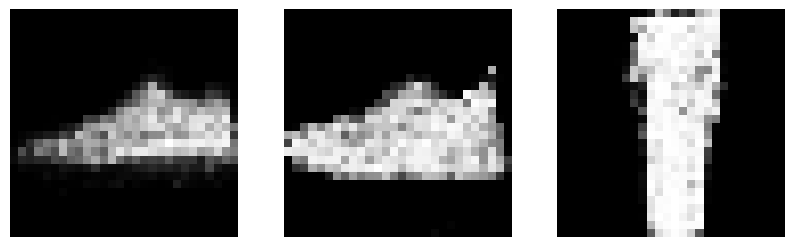

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to save and display 3 samples from your GAN model
def save_and_display_samples(num_samples=3):
    # Generate fake images
    fake_images = G(sample_vectors)
    fake_images = fake_images.reshape(fake_images.size(0), 28, 28).cpu().data.numpy()

    # Normalize the images back to [0,1] range
    fake_images = (fake_images + 1) / 2.0

    # Save and display the first 3 images
    fig, axes = plt.subplots(1, num_samples, figsize=(10, 5))

    for i in range(num_samples):
        axes[i].imshow(fake_images[i], cmap='gray')
        axes[i].axis('off')
        plt.savefig(f'sample_{i+1}.png')  # Save each sample as an image file
    plt.show()

# Call the function to save and display 3 samples
save_and_display_samples()

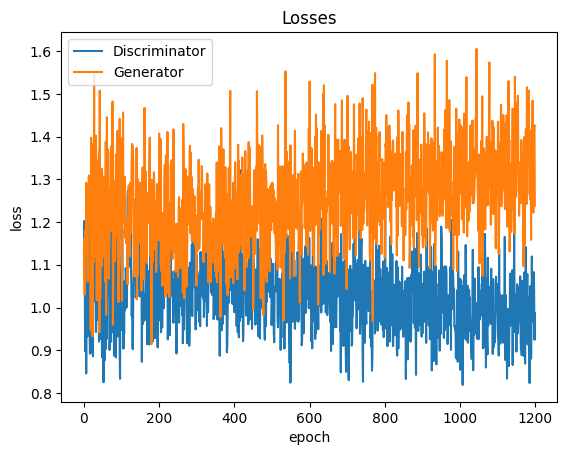

In [ ]:
plt.plot(d_losses, '-')
plt.plot(g_losses, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

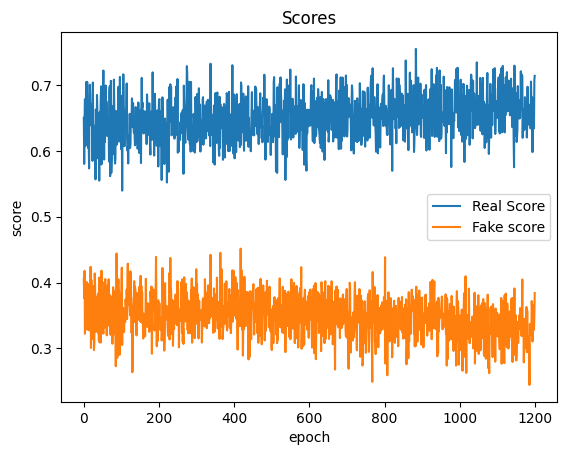

In [ ]:
plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real Score', 'Fake score'])
plt.title('Scores');

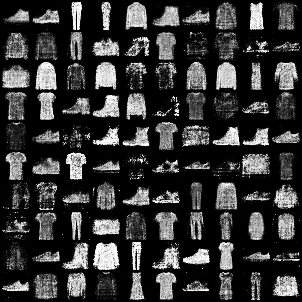

In [ ]:
Image('./samples/fake_images-0010.png')

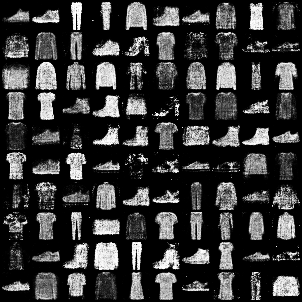

In [ ]:
Image('./samples/fake_images-0050.png')

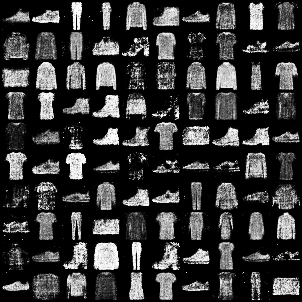

In [ ]:
Image('./samples/fake_images-0100.png')

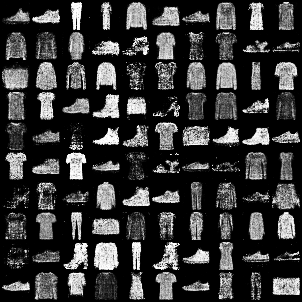

In [ ]:
Image('./samples/fake_images-0200.png')

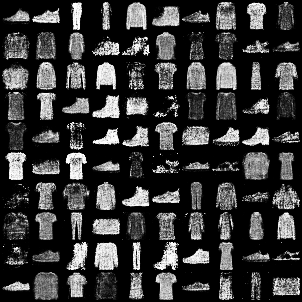

In [ ]:
Image('./samples/fake_images-0300.png')

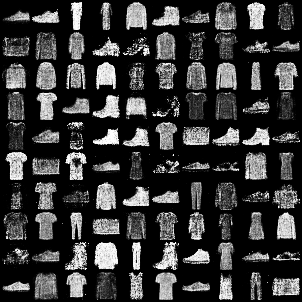

In [ ]:
Image('./samples/fake_images-0400.png')

part 2

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image
import os
from IPython.display import Image

# Hyperparameters
image_size = 28 * 28
latent_size = 64
hidden_size = 256
num_epochs = 200
batch_size = 100
learning_rate = 0.0002
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sample_dir = 'samples'

# Create the sample directory if it doesn't exist
os.makedirs(sample_dir, exist_ok=True)

# Data loader
data_loader = torch.utils.data.DataLoader(dataset=fashion_mnist,
                                          batch_size=batch_size,
                                          shuffle=True)

In [ ]:
# Define Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.model(x)

# Define Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, image_size),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Instantiate models
D = Discriminator().to(device)
G = Generator().to(device)

# Loss function for LSGAN
def least_squares_loss(outputs, labels):
    return torch.mean((outputs - labels) ** 2)

# Optimizers
d_optimizer = optim.Adam(D.parameters(), lr=learning_rate)
g_optimizer = optim.Adam(G.parameters(), lr=learning_rate)

In [ ]:
# Function to reset gradients
def reset_grad():
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

# Function to train the discriminator
def train_discriminator(images):
    # Create labels for real and fake images
    real_labels = torch.ones(batch_size, 1).to(device)  # Real label
    fake_labels = torch.zeros(batch_size, 1).to(device)  # Fake label

    # Loss for real images
    outputs = D(images)
    d_loss_real = least_squares_loss(outputs, real_labels)

    # Loss for fake images
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    outputs = D(fake_images)
    d_loss_fake = least_squares_loss(outputs, fake_labels)

    # Combine losses
    d_loss = d_loss_real + d_loss_fake

    # Reset gradients and optimize
    reset_grad()
    d_loss.backward()
    d_optimizer.step()

    return d_loss, outputs, fake_images

# Function to train the generator
def train_generator():
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    labels = torch.ones(batch_size, 1).to(device)  # Labels are all ones for generator loss
    g_loss = least_squares_loss(D(fake_images), labels)

    # Backprop and optimize
    reset_grad()
    g_loss.backward()
    g_optimizer.step()

    return g_loss, fake_images

# Saving a batch of real images
def save_real_images(data_loader):
    for images, _ in data_loader:
        images = images.reshape(images.size(0), -1).to(device)
        save_image(images.view(-1, 1, 28, 28), os.path.join(sample_dir, 'real_images.png'), nrow=10)
        break

def save_fake_images(index):
    fake_images = G(sample_vectors)
    fake_images = fake_images.view(fake_images.size(0), 1, 28, 28)
    fake_fname = 'fake_images-{0:0=4d}.png'.format(index)
    print('Saving', fake_fname)
    save_image(fake_images, os.path.join(sample_dir, fake_fname), nrow=10)

# Before training
sample_vectors = torch.randn(batch_size, latent_size).to(device)
save_real_images(data_loader)
save_fake_images(0)

Saving fake_images-0000.png


In [ ]:
# Training Loop
d_losses, g_losses, real_scores, fake_scores = [], [], [], []
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        images = images.reshape(batch_size, -1).to(device)

        # Train the discriminator and generator
        d_loss, real_score, fake_images = train_discriminator(images)
        g_loss, _ = train_generator()

        # Store scores for visualization
        real_scores.append(real_score.mean().item())  # Store the mean of real scores
        fake_scores.append(D(fake_images).mean().item())  # Get fake scores for visualization

        # Log losses and scores
        if (i + 1) % 200 == 0:
            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())
            print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}'
                  .format(epoch + 1, num_epochs, i + 1, len(data_loader), d_loss.item(), g_loss.item(),
                          real_score.mean().item(), D(fake_images).mean().item()))  # Print real and fake scores

    # Save generated images
    save_fake_images(epoch + 1)

Epoch [1/200], Step [200/600], d_loss: 0.4250, g_loss: 0.3780, D(x): 0.48, D(G(z)): 0.45
Epoch [1/200], Step [400/600], d_loss: 0.3253, g_loss: 0.5456, D(x): 0.32, D(G(z)): 0.31
Epoch [1/200], Step [600/600], d_loss: 0.2583, g_loss: 0.6675, D(x): 0.28, D(G(z)): 0.23
Saving fake_images-0001.png
Epoch [2/200], Step [200/600], d_loss: 0.3642, g_loss: 0.6327, D(x): 0.29, D(G(z)): 0.27
Epoch [2/200], Step [400/600], d_loss: 0.2262, g_loss: 0.5786, D(x): 0.22, D(G(z)): 0.18
Epoch [2/200], Step [600/600], d_loss: 0.2930, g_loss: 0.5732, D(x): 0.30, D(G(z)): 0.29
Saving fake_images-0002.png
Epoch [3/200], Step [200/600], d_loss: 0.3510, g_loss: 0.4765, D(x): 0.34, D(G(z)): 0.32
Epoch [3/200], Step [400/600], d_loss: 0.2897, g_loss: 0.5356, D(x): 0.27, D(G(z)): 0.25
Epoch [3/200], Step [600/600], d_loss: 0.3648, g_loss: 0.5399, D(x): 0.35, D(G(z)): 0.32
Saving fake_images-0003.png
Epoch [4/200], Step [200/600], d_loss: 0.2687, g_loss: 0.5758, D(x): 0.30, D(G(z)): 0.25
Epoch [4/200], Step [400/6

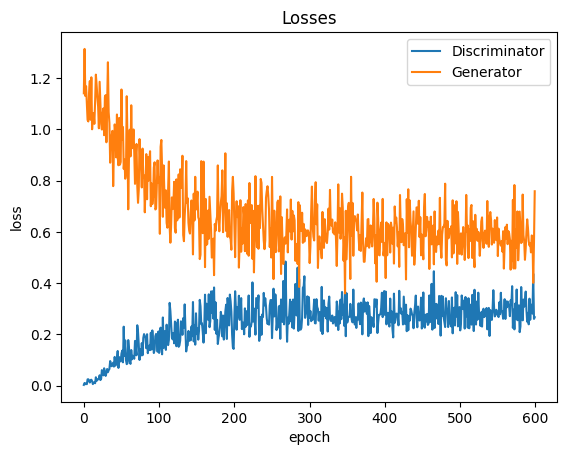

In [ ]:
plt.plot(d_losses, '-')
plt.plot(g_losses, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

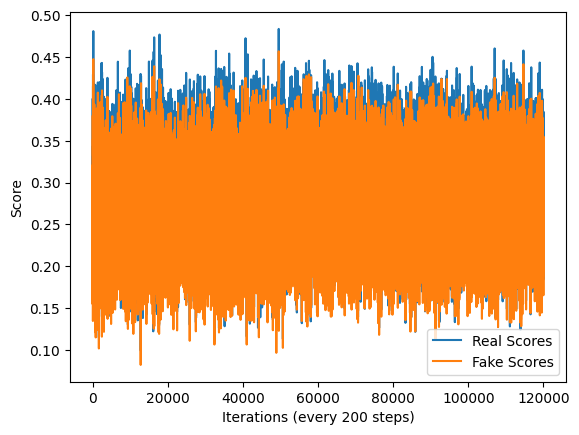

In [ ]:
# After training, you can visualize or plot the stored scores
import matplotlib.pyplot as plt
plt.plot(real_scores, label='Real Scores')
plt.plot(fake_scores, label='Fake Scores')
plt.xlabel('Iterations (every 200 steps)')
plt.ylabel('Score')
plt.legend()
plt.show()

In [ ]:
print(f'Real Scores Length: {len(real_scores)}, Fake Scores Length: {len(fake_scores)}')

Real Scores Length: 603, Fake Scores Length: 603


In [ ]:
print(f'Real Scores: {real_scores}')

Real Scores: [0.22710341215133667, 0.2858038544654846, 0.23585540056228638, 0.31159868836402893, 0.25603511929512024, 0.2541312873363495, 0.2938033938407898, 0.2763309180736542, 0.3182383179664612, 0.3496144711971283, 0.22761201858520508, 0.28672081232070923, 0.29006749391555786, 0.29451262950897217, 0.20865359902381897, 0.2727907598018646, 0.3247049152851105, 0.26791054010391235, 0.23242229223251343, 0.2549280822277069, 0.2611069083213806, 0.23649457097053528, 0.24563616514205933, 0.3409966230392456, 0.3268955647945404, 0.2681296169757843, 0.27229252457618713, 0.3358622193336487, 0.2582276165485382, 0.31488677859306335, 0.3520968556404114, 0.22877028584480286, 0.31173837184906006, 0.2145048975944519, 0.19648224115371704, 0.23569150269031525, 0.3145972490310669, 0.3745780885219574, 0.23556315898895264, 0.22729015350341797, 0.31132516264915466, 0.31965571641921997, 0.2797815501689911, 0.2412145882844925, 0.25706133246421814, 0.2863628566265106, 0.2430436611175537, 0.24577239155769348, 0

In [ ]:
print(f'Fake Scores: {fake_scores}')

Fake Scores: [0.22710341215133667, 0.2858038544654846, 0.23585540056228638, 0.31159868836402893, 0.25603511929512024, 0.2541312873363495, 0.2938033938407898, 0.2763309180736542, 0.3182383179664612, 0.3496144711971283, 0.22761201858520508, 0.28672081232070923, 0.29006749391555786, 0.29451262950897217, 0.20865359902381897, 0.2727907598018646, 0.3247049152851105, 0.26791054010391235, 0.23242229223251343, 0.2549280822277069, 0.2611069083213806, 0.23649457097053528, 0.24563616514205933, 0.3409966230392456, 0.3268955647945404, 0.2681296169757843, 0.27229252457618713, 0.3358622193336487, 0.2582276165485382, 0.31488677859306335, 0.3520968556404114, 0.22877028584480286, 0.31173837184906006, 0.2145048975944519, 0.19648224115371704, 0.23569150269031525, 0.3145972490310669, 0.3745780885219574, 0.23556315898895264, 0.22729015350341797, 0.31132516264915466, 0.31965571641921997, 0.2797815501689911, 0.2412145882844925, 0.25706133246421814, 0.2863628566265106, 0.2430436611175537, 0.24577239155769348, 0

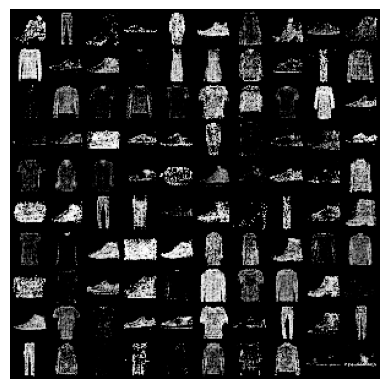

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Function to display saved fake images
def display_fake_images(index):
    # Load the saved image
    fake_fname = 'fake_images-{0:0=4d}.png'.format(index)
    img = Image.open(os.path.join(sample_dir, fake_fname))

    # Convert image to numpy array and display
    img = np.asarray(img)
    plt.imshow(img)
    plt.axis('off')  # Turn off the axis
    plt.show()

# Call display after each epoch
display_fake_images(epoch + 1)

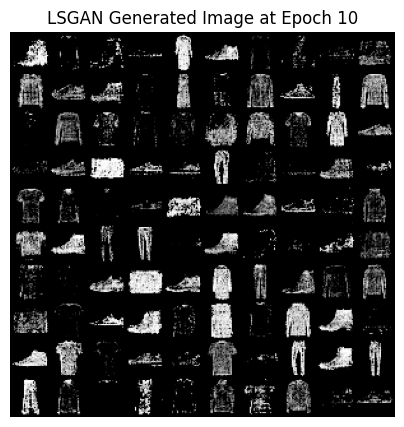

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Function to display a specific generated image from the LSGAN
def display_lsgan_image(epoch):
    # Construct the file path based on the epoch number
    img_path = './samples/fake_images-{0:0=4d}.png'.format(epoch)

    # Load the image
    img = mpimg.imread(img_path)

    # Display the image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')  # Turn off the axis
    plt.title(f'LSGAN Generated Image at Epoch {epoch}')
    plt.show()

# Example usage: display LSGAN-generated image at epoch 10
display_lsgan_image(10)

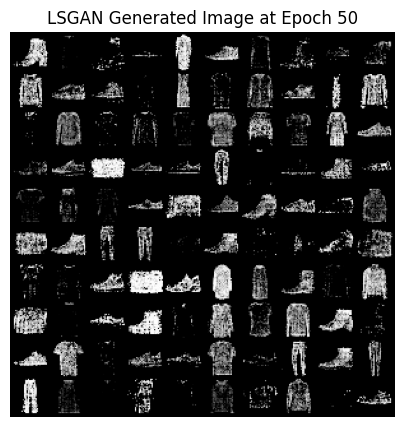

In [ ]:
display_lsgan_image(50)

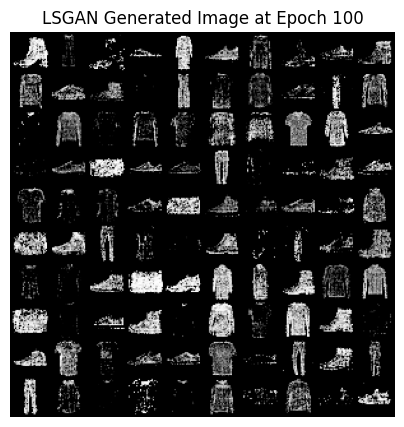

In [ ]:
display_lsgan_image(100)

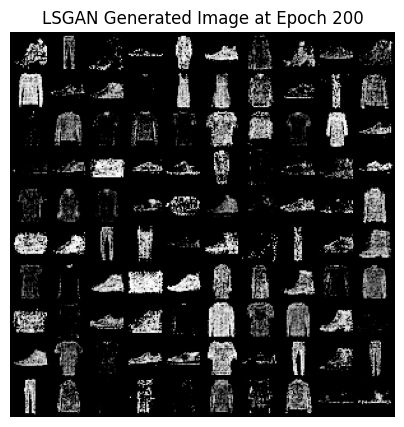

In [ ]:
display_lsgan_image(200)

Saving LSGAN model weights in a folder

In [ ]:
import os

# Define the directory to save the model weights
model_dir = 'model_weights_LSGAN'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the weights for the generator and discriminator models
torch.save(G.state_dict(), os.path.join(model_dir, 'generator_lsgan.pth'))
torch.save(D.state_dict(), os.path.join(model_dir, 'discriminator_lsgan.pth'))

print("successfully saved LSGAN model weights")

successfully saved LSGAN model weights


loading model using saved weights

In [ ]:
# Load the saved generator and discriminator weights
G.load_state_dict(torch.load(os.path.join(model_dir, 'generator_lsgan.pth')))
D.load_state_dict(torch.load(os.path.join(model_dir, 'discriminator_lsgan.pth')))

print("successfully loaded LSGAN model with saved weights")

successfully loaded LSGAN model with saved weights


Re-training the LSGAN model with different epochs and learning rate

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image
import os
from IPython.display import Image

# Hyperparameters
image_size = 28 * 28
latent_size = 64
hidden_size = 256
num_epochs = 400
batch_size = 100
learning_rate = 0.0001
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sample_dir = 'samples'  # Make sure this directory exists

# Create the sample directory if it doesn't exist
os.makedirs(sample_dir, exist_ok=True)

# Data loader
data_loader = torch.utils.data.DataLoader(dataset=fashion_mnist,
                                          batch_size=batch_size,
                                          shuffle=True)

In [ ]:
# Define Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.model(x)

# Define Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, image_size),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Instantiate models
D = Discriminator().to(device)
G = Generator().to(device)

# Loss function for LSGAN
def least_squares_loss(outputs, labels):
    return torch.mean((outputs - labels) ** 2)

# Optimizers
d_optimizer = optim.Adam(D.parameters(), lr=learning_rate)
g_optimizer = optim.Adam(G.parameters(), lr=learning_rate)

In [ ]:
# Function to reset gradients
def reset_grad():
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

# Function to train the discriminator
def train_discriminator(images):
    # Create labels for real and fake images
    real_labels = torch.ones(batch_size, 1).to(device)  # Real label
    fake_labels = torch.zeros(batch_size, 1).to(device)  # Fake label

    # Loss for real images
    outputs = D(images)
    d_loss_real = least_squares_loss(outputs, real_labels)

    # Loss for fake images
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    outputs = D(fake_images)
    d_loss_fake = least_squares_loss(outputs, fake_labels)

    # Combine losses
    d_loss = d_loss_real + d_loss_fake

    # Reset gradients and optimize
    reset_grad()
    d_loss.backward()
    d_optimizer.step()

    return d_loss, outputs, fake_images

# Function to train the generator
def train_generator():
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    labels = torch.ones(batch_size, 1).to(device)  # Labels are all ones for generator loss
    g_loss = least_squares_loss(D(fake_images), labels)

    # Backprop and optimize
    reset_grad()
    g_loss.backward()
    g_optimizer.step()

    return g_loss, fake_images

# Saving a batch of real images
def save_real_images(data_loader):
    for images, _ in data_loader:
        images = images.reshape(images.size(0), -1).to(device)
        save_image(images.view(-1, 1, 28, 28), os.path.join(sample_dir, 'real_images.png'), nrow=10)
        break

def save_fake_images(index):
    fake_images = G(sample_vectors)
    fake_images = fake_images.view(fake_images.size(0), 1, 28, 28)
    fake_fname = 'fake_images-{0:0=4d}.png'.format(index)
    print('Saving', fake_fname)
    save_image(fake_images, os.path.join(sample_dir, fake_fname), nrow=10)

# Before training
sample_vectors = torch.randn(batch_size, latent_size).to(device)
save_real_images(data_loader)
save_fake_images(0)

Saving fake_images-0000.png


In [ ]:
# Training Loop
d_losses, g_losses, real_scores, fake_scores = [], [], [], []
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        images = images.reshape(batch_size, -1).to(device)

        # Train the discriminator and generator
        d_loss, real_score, fake_images = train_discriminator(images)
        g_loss, _ = train_generator()

        # Store scores for visualization
        real_scores.append(real_score.mean().item())  # Store the mean of real scores
        fake_scores.append(D(fake_images).mean().item())  # Get fake scores for visualization

        # Log losses and scores
        if (i + 1) % 200 == 0:
            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())
            print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}'
                  .format(epoch + 1, num_epochs, i + 1, len(data_loader), d_loss.item(), g_loss.item(),
                          real_score.mean().item(), D(fake_images).mean().item()))  # Print real and fake scores

    # Save generated images
    save_fake_images(epoch + 1)

Epoch [1/400], Step [200/600], d_loss: 0.0167, g_loss: 1.1114, D(x): 0.02, D(G(z)): -0.07
Epoch [1/400], Step [400/600], d_loss: 0.0133, g_loss: 1.0848, D(x): 0.01, D(G(z)): -0.04
Epoch [1/400], Step [600/600], d_loss: 0.0124, g_loss: 1.1832, D(x): 0.02, D(G(z)): -0.08
Saving fake_images-0001.png
Epoch [2/400], Step [200/600], d_loss: 0.0107, g_loss: 1.1007, D(x): 0.04, D(G(z)): -0.05
Epoch [2/400], Step [400/600], d_loss: 0.0244, g_loss: 1.0906, D(x): 0.06, D(G(z)): -0.05
Epoch [2/400], Step [600/600], d_loss: 0.0143, g_loss: 1.0108, D(x): 0.04, D(G(z)): 0.00
Saving fake_images-0002.png
Epoch [3/400], Step [200/600], d_loss: 0.0115, g_loss: 1.1423, D(x): 0.02, D(G(z)): -0.06
Epoch [3/400], Step [400/600], d_loss: 0.0240, g_loss: 1.1551, D(x): -0.02, D(G(z)): -0.08
Epoch [3/400], Step [600/600], d_loss: 0.0214, g_loss: 1.0487, D(x): -0.02, D(G(z)): -0.03
Saving fake_images-0003.png
Epoch [4/400], Step [200/600], d_loss: 0.0203, g_loss: 1.1035, D(x): 0.08, D(G(z)): -0.05
Epoch [4/400], 

In [ ]:
# Save the model checkpoints
torch.save(G.state_dict(), 'G_LSGAN.ckpt')
torch.save(D.state_dict(), 'D_LSGAN.ckpt')

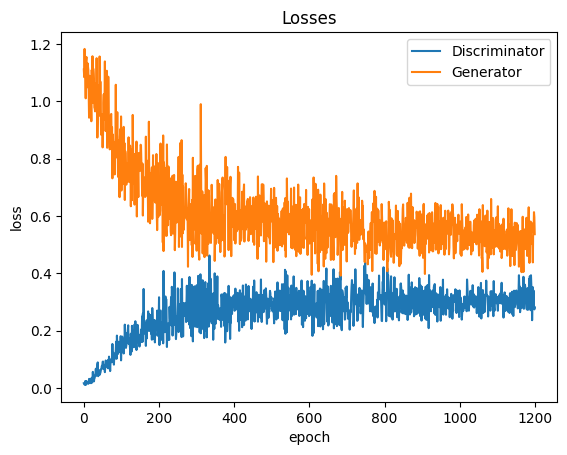

In [ ]:
plt.plot(d_losses, '-')
plt.plot(g_losses, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

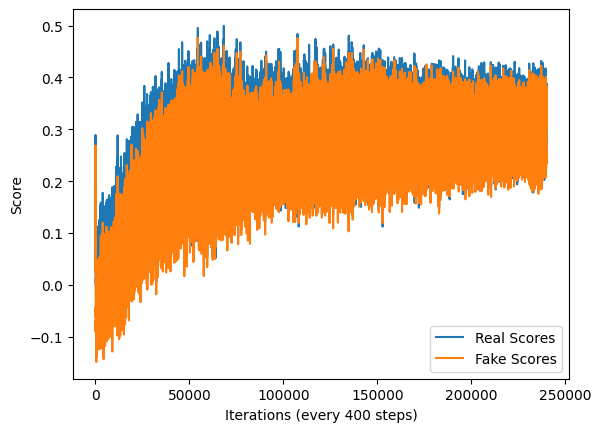

In [ ]:
# After training, you can visualize or plot the stored scores
import matplotlib.pyplot as plt
plt.plot(real_scores, label='Real Scores')
plt.plot(fake_scores, label='Fake Scores')
plt.xlabel('Iterations (every 400 steps)')
plt.ylabel('Score')
plt.legend()
plt.show()

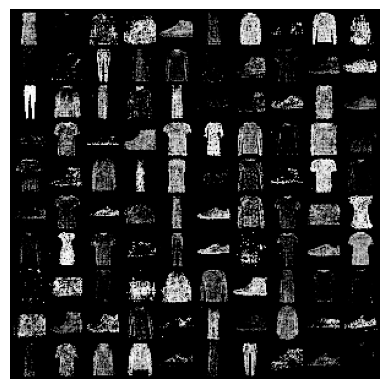

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Function to display saved fake images
def display_fake_images(index):
    # Load the saved image
    fake_fname = 'fake_images-{0:0=4d}.png'.format(index)
    img = Image.open(os.path.join(sample_dir, fake_fname))

    # Convert image to numpy array and display
    img = np.asarray(img)
    plt.imshow(img)
    plt.axis('off')  # Turn off the axis
    plt.show()

# Call display after each epoch
display_fake_images(epoch + 1)

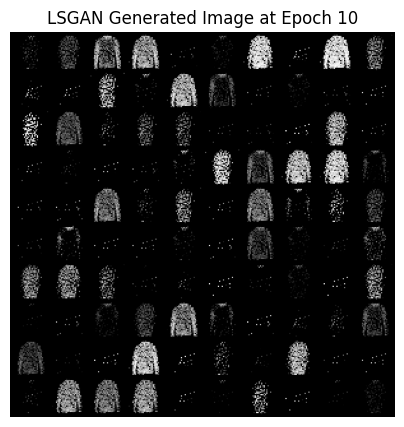

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Function to display a specific generated image from the LSGAN
def display_lsgan_image(epoch):
    # Construct the file path based on the epoch number
    img_path = './samples/fake_images-{0:0=4d}.png'.format(epoch)

    # Load the image
    img = mpimg.imread(img_path)

    # Display the image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')  # Turn off the axis
    plt.title(f'LSGAN Generated Image at Epoch {epoch}')
    plt.show()

# Example usage: display LSGAN-generated image at epoch 10
display_lsgan_image(10)

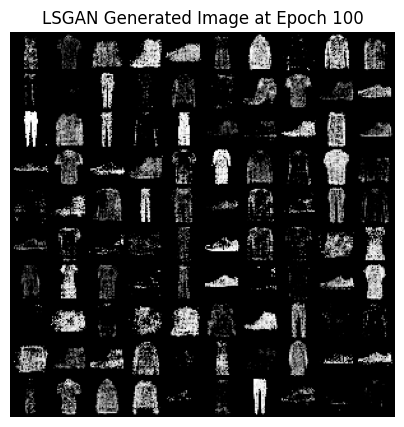

In [ ]:
display_lsgan_image(100)

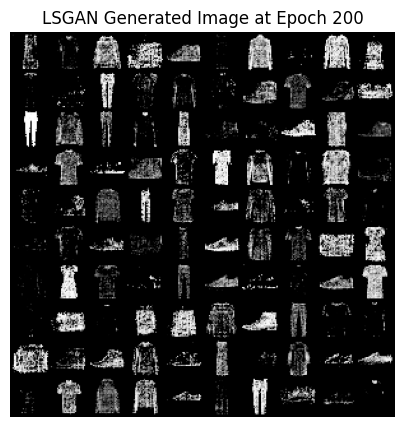

In [ ]:
display_lsgan_image(200)

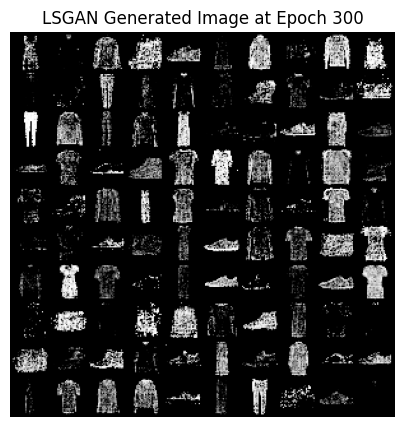

In [ ]:
display_lsgan_image(300)

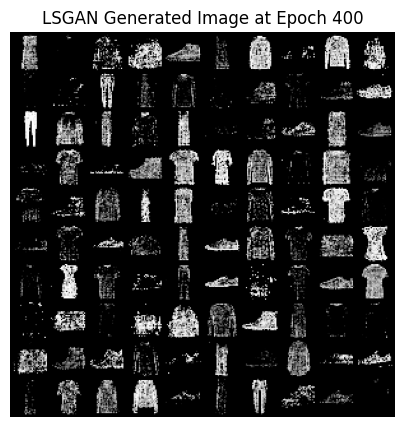

In [ ]:
display_lsgan_image(400)

In [ ]:
import os

# Define the directory to save the model weights
model_dir = 'model_weights_LSGAN'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the weights for the generator and discriminator models
torch.save(G.state_dict(), os.path.join(model_dir, 'generator_lsgan_weights.pth'))
torch.save(D.state_dict(), os.path.join(model_dir, 'discriminator_lsgan_weights.pth'))

print("successfully saved LSGAN model weights")

successfully saved LSGAN model weights


In [ ]:
# Load the saved generator and discriminator weights
G.load_state_dict(torch.load(os.path.join(model_dir, 'generator_lsgan.pth')))
D.load_state_dict(torch.load(os.path.join(model_dir, 'discriminator_lsgan.pth')))

print("successfully loaded LSGAN model with saved weights")

successfully loaded LSGAN model with saved weights
